In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim

import math

# Data Loading

In [2]:
# Load data
df = pd.read_csv("/home/dilith_s_b_s/UoP/Sem_4/CO5420/DLProject/beijing-pm25-forecasting/data/raw/train_raw.csv")

# Inspect
display(df.head())          # Show first 5 rows of the dataset
print(df.info())            # Information about the data columns
display(df.describe())      # Display statisticaly important data about each column of data

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


<class 'pandas.DataFrame'>
RangeIndex: 315648 entries, 0 to 315647
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       315648 non-null  int64  
 1   year     315648 non-null  int64  
 2   month    315648 non-null  int64  
 3   day      315648 non-null  int64  
 4   hour     315648 non-null  int64  
 5   PM2.5    309276 non-null  float64
 6   PM10     311033 non-null  float64
 7   SO2      308661 non-null  float64
 8   NO2      305989 non-null  float64
 9   CO       297542 non-null  float64
 10  O3       305471 non-null  float64
 11  TEMP     315469 non-null  float64
 12  PRES     315468 non-null  float64
 13  DEWP     315464 non-null  float64
 14  RAIN     315472 non-null  float64
 15  wd       314973 non-null  str    
 16  WSPM     315470 non-null  float64
 17  station  315648 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 43.3 MB
None


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,315648.000000,315648.000000,315648.000000,315648.000000,315648.000000,309276.000000,311033.000000,308661.000000,305989.000000,297542.000000,305471.000000,315469.000000,315468.000000,315464.000000,315472.000000,315470.000000
mean,13152.500000,2014.163321,6.521898,15.732664,11.500000,80.362399,105.667922,17.811413,51.242265,1242.387102,57.278001,13.392030,1010.645133,2.408688,0.060786,1.708060
std,7593.322763,0.896958,3.448992,8.801384,6.922198,80.169311,91.023870,23.512800,35.002673,1134.971064,56.635359,11.447169,10.467822,13.858515,0.794995,1.267147
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,6576.750000,2013.000000,4.000000,8.000000,5.750000,21.000000,36.000000,3.000000,24.000000,500.000000,11.000000,3.000000,1002.200000,-9.100000,0.000000,0.900000
50%,13152.500000,2014.000000,7.000000,16.000000,11.500000,56.000000,84.000000,9.000000,44.000000,900.000000,45.000000,14.400000,1010.300000,3.000000,0.000000,1.400000
75%,19728.250000,2015.000000,10.000000,23.000000,17.250000,113.000000,148.000000,22.000000,72.000000,1600.000000,82.000000,23.100000,1019.000000,15.200000,0.000000,2.200000
max,26304.000000,2016.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


# Exploratory Data Analysis

In [3]:
# 1. Drop the 'No' column
df = df.drop(columns=['No'])

# 2. Create a datetime column using pd.to_datetime
# Pandas can automatically parse a dataframe if it has year, month, day, hour columns!
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# 3. Calculate missing values percentage
# df.isnull().sum() gives total missing. Divide by len(df) and multiply by 100 for percentage.
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Print the percentages, rounded to 2 decimal places
print(missing_percentages.round(2).sort_values(ascending=False))

CO          5.74
O3          3.22
NO2         3.06
SO2         2.21
PM2.5       2.02
PM10        1.46
wd          0.21
WSPM        0.06
RAIN        0.06
TEMP        0.06
DEWP        0.06
PRES        0.06
month       0.00
year        0.00
hour        0.00
day         0.00
station     0.00
datetime    0.00
dtype: float64


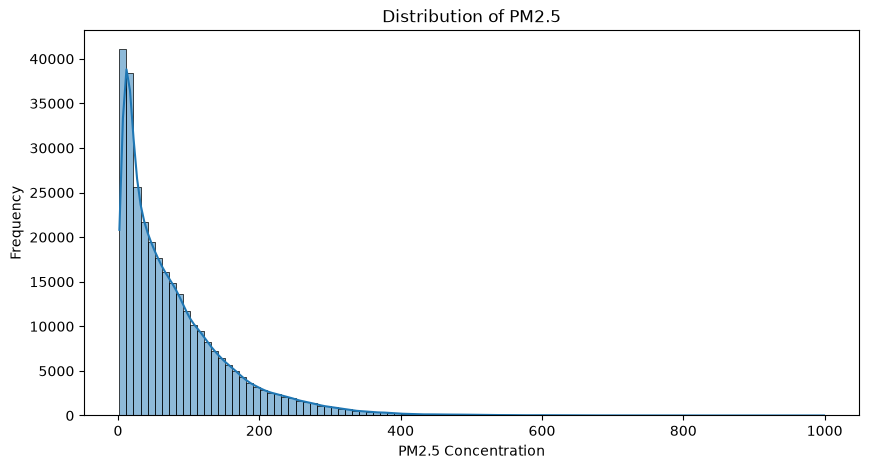

Plotting for station: Aotizhongxin


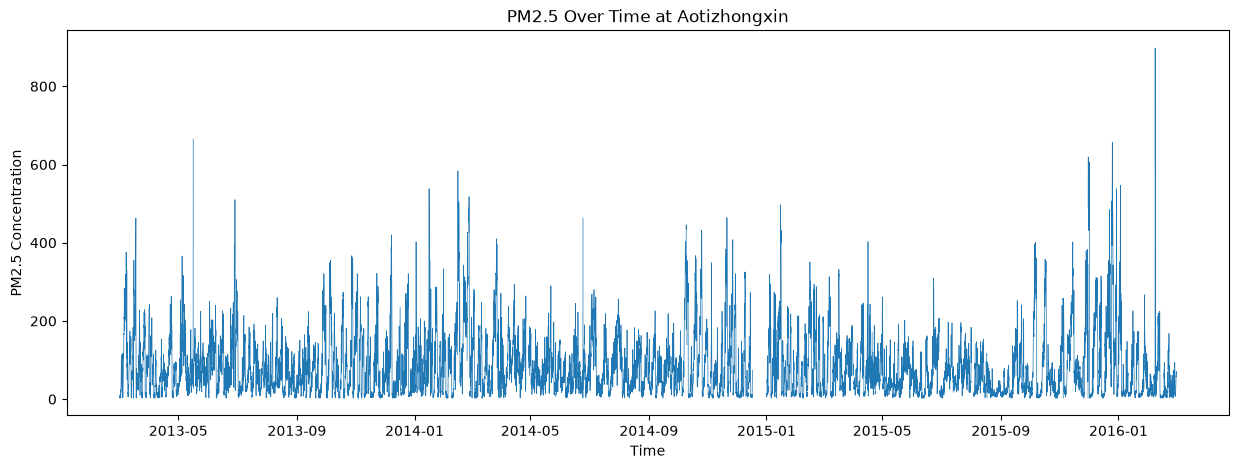

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Plot the distribution of PM2.5
plt.figure(figsize=(10, 5))
sns.histplot(df['PM2.5'].dropna(), bins=100, kde=True)
plt.title('Distribution of PM2.5')
plt.xlabel('PM2.5 Concentration')
plt.ylabel('Frequency')
plt.show()

# 2. Get the first station's name
first_station = df['station'].unique()[0]
print(f"Plotting for station: {first_station}")

# 3. Filter data for just this station
station_df = df[df['station'] == first_station]

# 4. Plot PM2.5 over time for this station
plt.figure(figsize=(15, 5))
plt.plot(station_df['datetime'], station_df['PM2.5'], linewidth=0.5)
plt.title(f'PM2.5 Over Time at {first_station}')
plt.xlabel('Time')
plt.ylabel('PM2.5 Concentration')
plt.show()

## Distribution of PM2.5

* **Right-Skewed Distribution:** This is not a symmetric bell curve. It is heavily **right-skewed** (or positively skewed).

* **The Physical Reality:** The massive spike on the left tells us that for the vast majority of hours, PM2.5 levels are relatively low (between 0 and 100 $\mu g/m^3$).

* **The Extreme Tail:** Look at how the tail stretches all the way out to 1000. These are extreme smog events. Even though they are rare, they are real.

* **Why this matters for RMSE Metric:** RMSE squares the errors. If the model simply predicts the "normal" value of around 50 every day, it will be completely wrong during an extreme smog event (say, an actual value of 800). The model *must* learn to predict these spikes!


## PM2.5 Over Time at Aotizhongxin

* **Strong Seasonality:** The clusters of massive spikes (the ones reaching 600–800) consistently occur around the turn of the year (Dec, Jan, Feb). This aligns with Beijing's winter heating season (coal burning) and specific atmospheric conditions that trap pollutants. Summer months generally have a lower, more stable baseline.

* **High Volatility:** The value doesn't just smoothly drift up and down; it violently swings from near 0 to 500+ and back down within extremely short timeframes. This means relying strictly on "recent averages" (like moving averages) won't be enough. The neural network will need to learn the *conditions* that cause these sudden spikes.

* **Visible Missing Data:** Empty gaps in the blue line (A prominent gap right after Jan 2015) are the visual representations of the 2.02% missing values calculated earlier. The sensors literally went offline in those time period.

## Feature Correlation

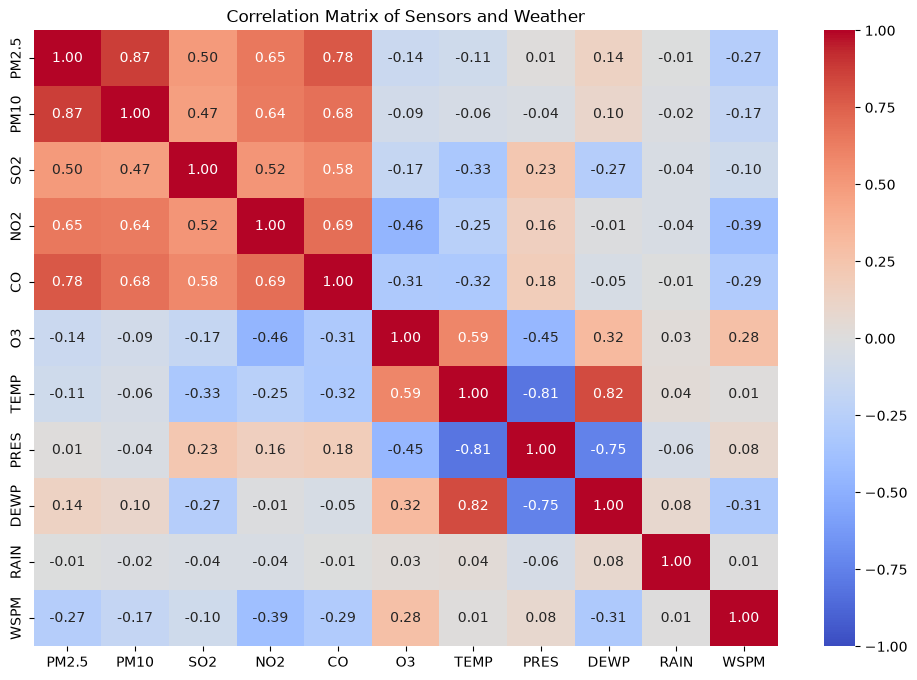

Correlation with PM2.5:
PM2.5    1.000000
PM10     0.873184
CO       0.777572
NO2      0.649875
SO2      0.498742
DEWP     0.137781
PRES     0.009655
RAIN    -0.005765
TEMP    -0.106312
O3      -0.137380
WSPM    -0.266632
Name: PM2.5, dtype: float64


In [5]:
# 1. Select the relevant numerical columns (excluding the time integer columns)
sensor_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# 2. Calculate the correlation matrix
corr_matrix = df[sensor_cols].corr()

# 3. Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Sensors and Weather')
plt.show()

# 4. Print correlations specifically with PM2.5, sorted from highest to lowest
print("Correlation with PM2.5:")
print(corr_matrix['PM2.5'].sort_values(ascending=False))

Key takeaways to use when building the model:

* **The Strongest Positive Predictors:**

* **PM10 (0.87):** There is a massive correlation between PM2.5 and PM10. It makes perfect physical sense because PM10 and PM2.5 are both particulate matter often originating from the exact same sources (dust, combustion, industrial emissions).

* **CO (0.78) & NO2 (0.65):** Carbon Monoxide and Nitrogen Dioxide are heavily tied to PM2.5. Because they are primary byproducts of burning fossil fuels (vehicle exhaust and coal heating). When traffic is heavy or coal is burning, all three of these spike together.


* **The "Clearing" Factors (Negative Correlation):**

* **WSPM (-0.27):** Wind Speed is the strongest negative correlate. When wind speed goes up, PM2.5 goes down. This is the physical mechanism of wind blowing the stagnant smog out of the Beijing basin.

* **TEMP (-0.11):** A slight negative correlation. This confirms what we saw in your line plot earlier—colder temperatures (winter) generally align with higher PM2.5 spikes due to heating demands and atmospheric inversions.


